In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import torch.optim as optim



import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, Subset

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=train_transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# 1. SE Block (Channel Attention)
# -----------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

    def forward(self, x):
        b, c, h, w = x.size()
        y = x.view(b, c, -1).mean(dim=2)
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y))
        y = y.view(b, c, 1, 1)
        return x * y


# -----------------------------
# 2. Spatial Attention
# -----------------------------
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg, mx], dim=1)
        attn = torch.sigmoid(self.conv(x_cat))
        return x * attn


# -----------------------------
# 3. Multi-Scale Block
# -----------------------------
class MultiScaleBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv3 = nn.Conv2d(in_channels, out_channels, 3, stride, 1)
        self.conv5 = nn.Conv2d(in_channels, out_channels, 5, stride, 2)

        self.bn = nn.BatchNorm2d(out_channels * 2)

    def forward(self, x):
        x1 = self.conv3(x)
        x2 = self.conv5(x)
        x = torch.cat([x1, x2], dim=1)
        return F.relu(self.bn(x))


# -----------------------------
# 4. Advanced Residual Block
# -----------------------------
class AdvancedBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample=False):
        super().__init__()

        stride = 2 if downsample else 1

        self.ms = MultiScaleBlock(in_channels, out_channels // 2, stride)
        self.conv = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        self.bn = nn.BatchNorm2d(out_channels)

        self.se = SEBlock(out_channels)
        self.sa = SpatialAttention()

        if downsample or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.ms(x)
        out = self.bn(self.conv(out))

        out = self.se(out)
        out = self.sa(out)

        out += identity
        return F.relu(out)


# -----------------------------
# 5. Final Model
# -----------------------------
class ResumeLevelFashionModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        # Feature extractor
        self.layer1 = AdvancedBlock(32, 64)
        self.layer2 = AdvancedBlock(64, 128, downsample=True)
        self.layer3 = AdvancedBlock(128, 256, downsample=True)

        self.pool = nn.AdaptiveAvgPool2d(1)

        # Embedding head
        self.embedding = nn.Linear(256, 128)

        # Classifier
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

        # Auxiliary classifier
        self.aux_head = nn.Linear(128, num_classes)

        self.features = {}

    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        self.features['layer1'] = x

        x = self.layer2(x)
        self.features['layer2'] = x

        x = self.layer3(x)
        self.features['layer3'] = x

        x = self.pool(x).view(x.size(0), -1)

        embedding = self.embedding(x)
        self.features['embedding'] = embedding

        out = self.classifier(embedding)

        aux_out = self.aux_head(embedding)

        return out, aux_out, embedding

In [61]:
model = ResumeLevelFashionModel().to(device)

CE= nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_losses, test_accuracies = [], []


In [62]:
# -----------------------------
# Early Stopping Params
# -----------------------------
patience = 3
counter = 0
best_acc = 0

EPOCHS = 20  # you can increase now

train_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        out, aux_out, embedding = model(images)

        loss_main = CE(out, labels)
        loss_aux = CE(aux_out, labels)
        loss = loss_main + 0.3 * loss_aux

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # Evaluation
    acc = evaluate(model, test_loader, device)

    train_losses.append(avg_loss)
    test_accuracies.append(acc)

    # -----------------------------
    # Early Stopping Logic
    # -----------------------------
    if acc > best_acc:
        best_acc = acc
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Test Acc={acc:.4f}")

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1: Loss=1.4269, Test Acc=0.7853
Epoch 2: Loss=0.7108, Test Acc=0.8145
Epoch 3: Loss=0.5968, Test Acc=0.8411
Epoch 4: Loss=0.5396, Test Acc=0.8517
Epoch 5: Loss=0.4991, Test Acc=0.8720
Epoch 6: Loss=0.4699, Test Acc=0.8644
Epoch 7: Loss=0.4447, Test Acc=0.8725
Epoch 8: Loss=0.4274, Test Acc=0.8496


KeyboardInterrupt: 

In [ ]:
import torch

# -----------------------------
# Evaluation Function
# -----------------------------
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            out, _, _ = model(images)   # only main output
            preds = out.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


# -----------------------------
# Training Loop
# -----------------------------
EPOCHS = 10

train_losses = []
test_accuracies = []

best_acc = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass (3 outputs)
        out, aux_out, embedding = model(images)

        # Loss calculation
        loss_main = CE(out, labels)
        loss_aux = CE(aux_out, labels)

        loss = loss_main + 0.3 * loss_aux

        # Backpropagation
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # Evaluation
    acc = evaluate(model, test_loader, device)

    train_losses.append(avg_loss)
    test_accuracies.append(acc)

    # Save best model
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Test Acc={acc:.4f}")

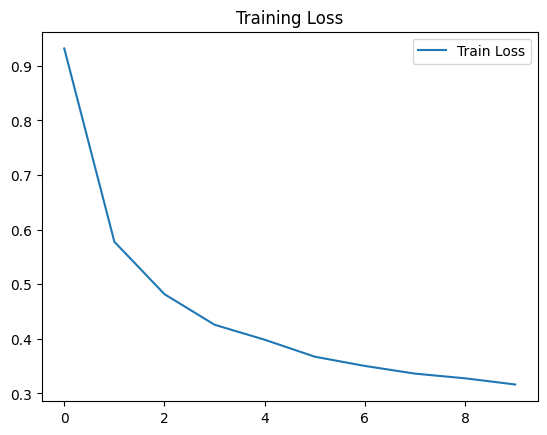

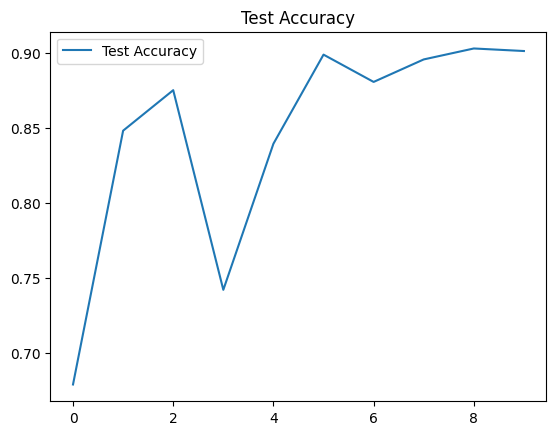

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.legend()
plt.title("Training Loss")
plt.show()

plt.figure()
plt.plot(test_accuracies, label="Test Accuracy")
plt.legend()
plt.title("Test Accuracy")
plt.show()

In [11]:
#Feature Extraction

In [12]:
import numpy as np

def extract_features(model, loader, layer_name='embedding'):
    model.eval()

    features = []
    labels_all = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            _ = model(images)  # forward pass
            feats = model.features[layer_name]

            feats = feats.view(feats.size(0), -1).cpu().numpy()

            features.append(feats)
            labels_all.append(labels.numpy())

    return np.vstack(features), np.hstack(labels_all)

In [13]:
#t-SNE Visualization

In [14]:
from sklearn.manifold import TSNE

# Extract features
features, labels = extract_features(model, test_loader, 'embedding')

# Reduce size (important for speed)
idx = np.random.choice(len(features), 2000, replace=False)
features_subset = features[idx]
labels_subset = labels[idx]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30)
reduced = tsne.fit_transform(features_subset)

In [15]:
#Plot t-SNE

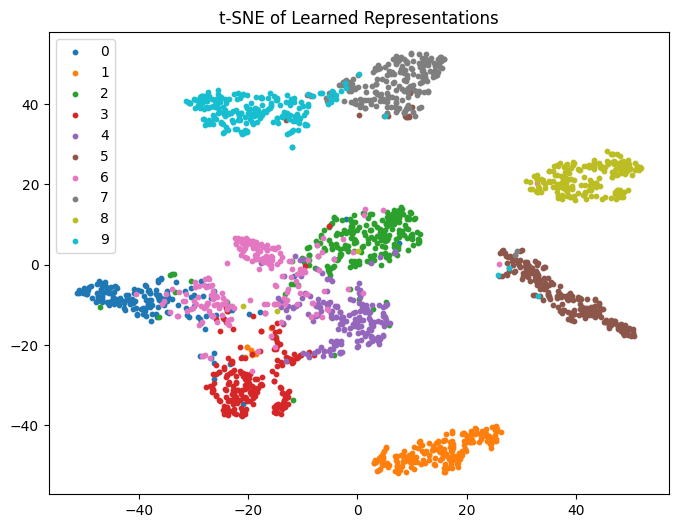

In [16]:
plt.figure(figsize=(8,6))

for i in range(10):
    points = reduced[labels_subset == i]
    plt.scatter(points[:,0], points[:,1], label=str(i), s=10)

plt.legend()
plt.title("t-SNE of Learned Representations")
plt.show()

In [17]:
#Compare Layers

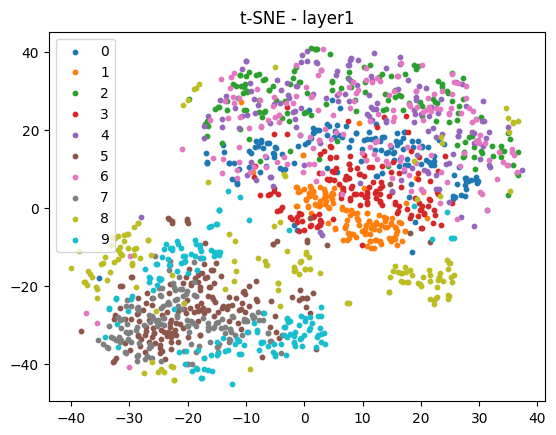

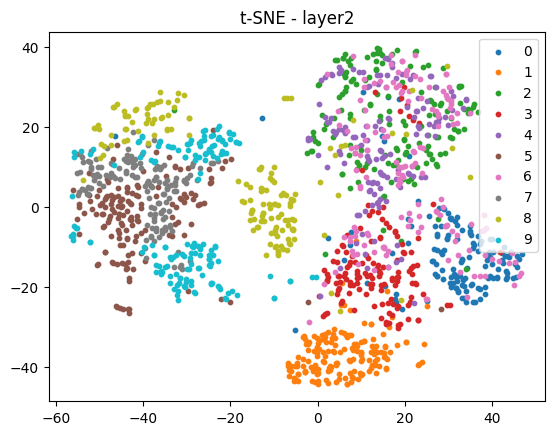

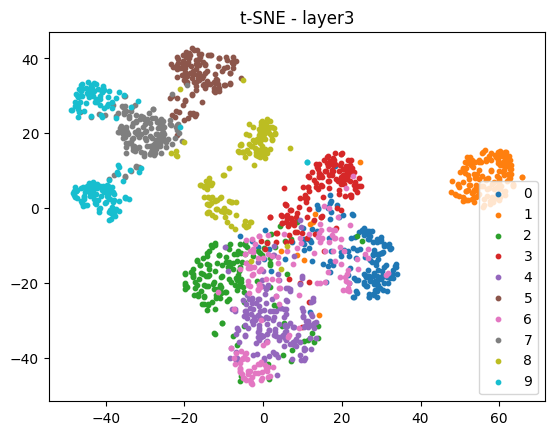

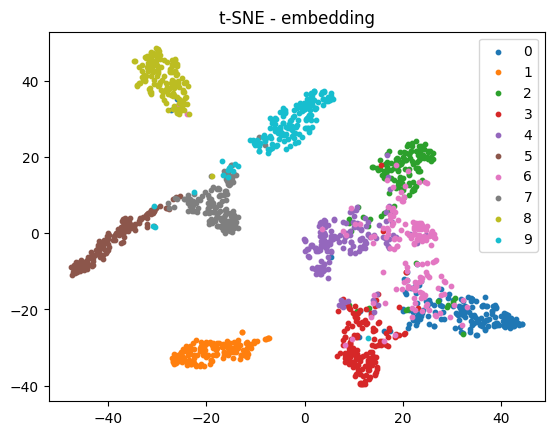

In [18]:
layers = ['layer1', 'layer2', 'layer3', 'embedding']

for layer in layers:
    feats, labels = extract_features(model, test_loader, layer)

    idx = np.random.choice(len(feats), 1500, replace=False)
    feats = feats[idx]
    labels_sub = labels[idx]

    reduced = TSNE(n_components=2).fit_transform(feats)

    plt.figure()
    for i in range(10):
        pts = reduced[labels_sub == i]
        plt.scatter(pts[:,0], pts[:,1], s=10, label=str(i))

    plt.legend()
    plt.title(f"t-SNE - {layer}")
    plt.show()

Failure Analysis

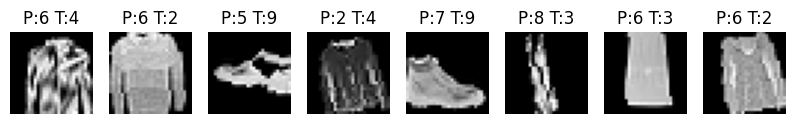

In [25]:
def show_misclassified(model, loader):
    model.eval()

    images_list = []
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device) # Ensure labels are on the device

            outputs = model(images)

            # Corrected: Access the first element of the tuple (main output) and then get argmax
            preds = outputs[0].argmax(dim=1)

            mask = preds != labels

            if mask.sum() > 0:
                images_list.append(images[mask].cpu()) # Perform masking on device, then move to CPU
                preds_list.append(preds[mask].cpu())   # Perform masking on device, then move to CPU
                labels_list.append(labels[mask].cpu()) # Perform masking on device, then move to CPU

            if len(images_list) > 3:
                break

    imgs = torch.cat(images_list)[:8]
    preds = torch.cat(preds_list)[:8]
    labels = torch.cat(labels_list)[:8]

    plt.figure(figsize=(10,3))
    for i in range(len(imgs)):
        plt.subplot(1, len(imgs), i+1)
        plt.imshow(imgs[i].squeeze(), cmap='gray')
        plt.title(f"P:{preds[i]} T:{labels[i]}")
        plt.axis('off')
    plt.show()

show_misclassified(model, test_loader)

# END


In [26]:
#1. Class Names (Fashion-MNIST)
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress",
    "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Prediction Function

In [32]:
import torch.nn.functional as F

def predict_image(model, image_tensor):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output, _, _ = model(image_tensor) # Unpack the tuple, use only the main output
        probs = F.softmax(output, dim=1)

    conf, pred = torch.max(probs, dim=1)

    return pred.item(), conf.item()

# Saliency Map (Explain Model Decision)

In [34]:
def get_saliency_map(model, image_tensor):
    model.eval()

    image_tensor = image_tensor.unsqueeze(0).to(device)
    image_tensor.requires_grad_()

    # The model returns a tuple (main_output, aux_output, embedding)
    # We need to get argmax from the main_output
    outputs = model(image_tensor)
    pred_class = outputs[0].argmax()

    # Backpropagate only through the predicted class from the main output
    outputs[0][0, pred_class].backward()

    saliency = image_tensor.grad.abs().squeeze().cpu()
    return saliency

In [ ]:
#Interactive Visualization Function

In [29]:
import matplotlib.pyplot as plt

def visualize_prediction(model, image, label=None):
    pred, conf = predict_image(model, image)
    saliency = get_saliency_map(model, image)

    plt.figure(figsize=(10,4))

    # Original Image
    plt.subplot(1,2,1)
    plt.imshow(image.squeeze(), cmap='gray')
    title = f"Pred: {class_names[pred]} ({conf:.2f})"
    if label is not None:
        title += f"\nTrue: {class_names[label]}"
    plt.title(title)
    plt.axis('off')

    # Saliency Map
    plt.subplot(1,2,2)
    plt.imshow(saliency, cmap='hot')
    plt.title("Saliency Map (What model looks at)")
    plt.axis('off')

    plt.show()

In [ ]:
#Test with Dataset Input

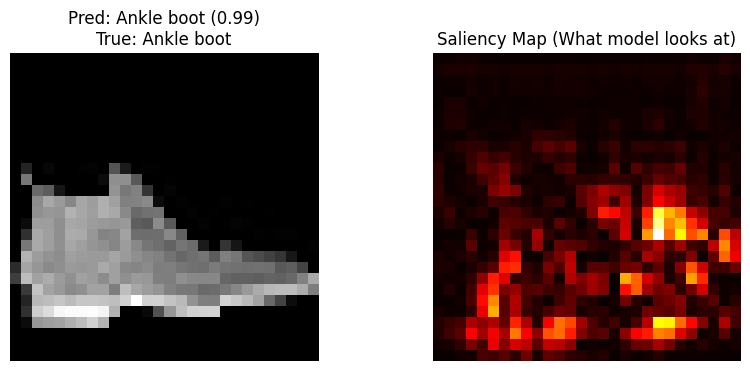

In [35]:
# Get one sample
image, label = test_dataset[0]

visualize_prediction(model, image, label)

In [31]:
#Custom Input (User-style)

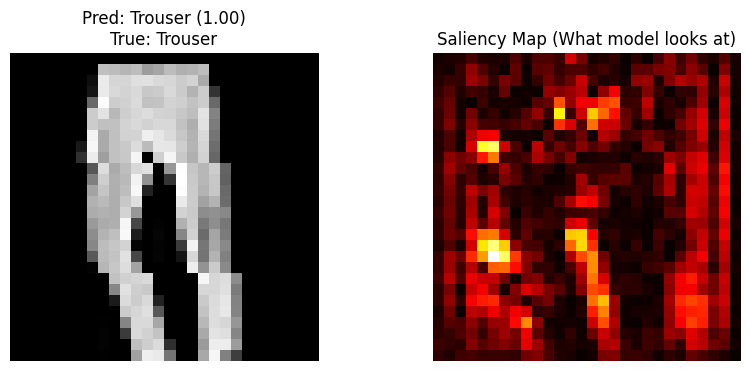

In [36]:
def predict_from_loader(model, loader, index=0):
    images, labels = next(iter(loader))
    image = images[index]
    label = labels[index]

    visualize_prediction(model, image, label)

predict_from_loader(model, test_loader, index=5)

In [ ]:
#Real Image Input

In [ ]:
from PIL import Image

def load_custom_image(path):
    transform = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((28,28)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    img = Image.open(path)
    return transform(img)

img = load_custom_image("/content/images.jpeg")
visualize_prediction(model, img)

In [ ]:
# Grad-CAM

In [37]:
# Hook storage
feature_maps = []
gradients = []

def forward_hook(module, input, output):
    feature_maps.append(output)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

Register Hook

In [39]:
# Example: last conv in layer3
target_layer = model.layer3.conv

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

# Grad-CAM Function

In [43]:
import torch
import torch.nn.functional as F

def generate_gradcam(model, image_tensor):
    model.eval()

    global feature_maps, gradients
    feature_maps = []
    gradients = []

    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Forward
    outputs = model(image_tensor) # outputs is a tuple (main_out, aux_out, embedding)
    main_output = outputs[0]     # Get the main output tensor
    pred_class = main_output.argmax() # Call argmax on the tensor

    # Backward
    model.zero_grad()
    # Backpropagate only through the predicted class from the main output
    main_output[0, pred_class].backward(retain_graph=True)

    # Get stored values
    fmap = feature_maps[0].squeeze(0)  # Remove batch dimension
    grad = gradients[0].squeeze(0)      # Remove batch dimension

    # Global average pooling on gradients
    weights = grad.mean(dim=(1,2))  # Mean over H, W

    # Weighted sum
    cam = torch.zeros(fmap.shape[1:], device=device)

    for i, w in enumerate(weights):
        cam += w * fmap[i]

    cam = F.relu(cam)

    # Normalize
    cam -= cam.min()
    cam /= cam.max()

    return cam.detach().cpu()

In [41]:
import matplotlib.pyplot as plt

def visualize_gradcam(model, image, label=None):
    pred, conf = predict_image(model, image)
    cam = generate_gradcam(model, image)

    plt.figure(figsize=(10,4))

    # Original
    plt.subplot(1,2,1)
    plt.imshow(image.squeeze(), cmap='gray')
    title = f"Pred: {class_names[pred]} ({conf:.2f})"
    if label is not None:
        title += f"\nTrue: {class_names[label]}"
    plt.title(title)
    plt.axis('off')

    # Grad-CAM
    plt.subplot(1,2,2)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


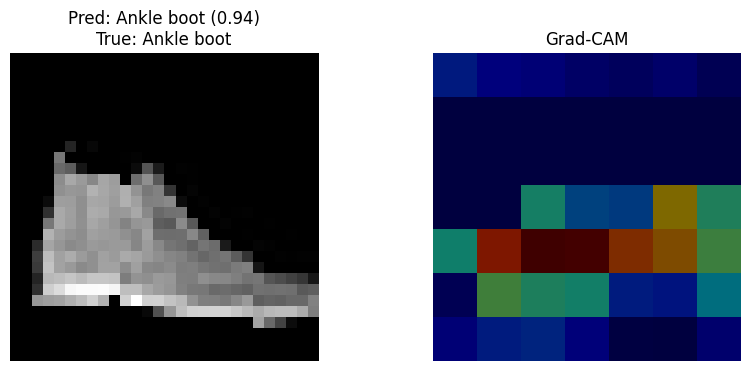

In [46]:
image, label = test_dataset[30]
visualize_gradcam(model, image, label)

In [ ]:
from PIL import Image

def load_custom_image(path):
    transform = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((28,28)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    img = Image.open(path)
    return transform(img)

img = load_custom_image("/content/images.jpeg")
visualize_gradcam(model, img)